In [1]:
!pip install datasets[audio] librosa transformers

# Data preprocessing   
loading data

In [51]:
from datasets import load_dataset

dataset = load_dataset("acul3/voxceleb2", split="train",streaming=True)

Resolving data files:   0%|          | 0/215 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/215 [00:00<?, ?it/s]

Take one example to see how audio works

In [52]:
sample = next(iter(dataset))
print(sample)
audio = sample["audio_path"]

array = audio["array"]
sr = audio["sampling_rate"]

print(array.shape)
print(sr)

{'audio_path': <datasets.features._torchcodec.AudioDecoder object at 0x7fb637565070>, 'transcription': ' What simply sounds good and you wind up in some way trying to, you know, eventually accessing the truth about your condition.', 'language': 'en', 'speaker_id': 'id03701', 'gender': 'male'}
(155136,)
24000


In [53]:
from IPython.display import Audio
Audio(array, rate=sr)

Count speakers and the number of audio files per speaker (already save to json and csv files)

In [54]:
import pandas as pd
from collections import Counter

# speakers = set()
# speaker_count = Counter()

# for ex in dataset:
#     speakers.add(ex["speaker_id"])
#     speaker_count[ex["speaker_id"]] += 1

df = pd.read_csv("speaker_count.csv")
speaker_count = Counter(
    dict(zip(df["speaker_id"], df["count"]))
)


In [55]:
counts = list(speaker_count.values())
print("num speakers:", len(counts))
print("min:", min(counts))
print("max:", max(counts))
print("avg:", sum(counts)/len(counts))

num speakers: 3232
min: 1
max: 500
avg: 143.2085396039604




* Filter speakers with insufficient data  (<100 utterances).  
* Create speaker-to-id and id-to-speaker
* count distribution after filtering.




In [56]:
import numpy as np

# Original distribution
counts = np.array(list(speaker_count.values()))

print("Before filtering:")
print(np.percentile(counts, [25, 50, 75, 90, 95]))

# Filter speakers
MIN_PER_SPEAKER = 100

valid_speakers = [
    spk for spk, count in speaker_count.items()
    if count >= MIN_PER_SPEAKER
]

valid_speakers = sorted(valid_speakers)

speaker2id = {spk: i for i, spk in enumerate(valid_speakers)}
id2speaker = {i: spk for spk, i in speaker2id.items()}

print("valid speakers:", len(valid_speakers))

# Distribution after filtering
filtered_counts = np.array(
    [speaker_count[spk] for spk in valid_speakers]
)

print("After filtering:")
df = pd.DataFrame({
    "speaker_id": valid_speakers,
    "count": [speaker_count[s] for s in valid_speakers]
})

print(df["count"].describe())

Before filtering:
[ 35.   92.  214.  374.9 482. ]
valid speakers: 1532
After filtering:
count    1532.000000
mean      257.360966
std       127.098144
min       100.000000
25%       148.000000
50%       224.500000
75%       351.250000
max       500.000000
Name: count, dtype: float64


Save speaker_count, speaker2id, id2speaker to files

In [41]:
# import json

# speaker_count_df = pd.DataFrame({
#     "speaker_id": list(speaker_count.keys()),
#     "count": list(speaker_count.values())
# })

# speaker_count_df = speaker_count_df.sort_values(
#     "count",
#     ascending=False
# )

# speaker_count_df.to_csv(
#     "speaker_count.csv",
#     index=False
# )

# with open("speaker2id.json", "w") as f:
#     json.dump(speaker2id, f, indent=2)

# with open("id2speaker.json", "w") as f:
#     json.dump(id2speaker, f, indent=2)

Filter out non-English recordings and remove speakers with fewer than 100 audio samples.

In [57]:
valid_speakers = set(valid_speakers)

dataset = dataset.filter(
    lambda ex:
        ex["language"] == "en"
        and ex["speaker_id"] in valid_speakers
)

Preprocess data change sample rate to 16k and transfer to log mel spectrogram save as input_features, save speaker_ids to label, remove the original columns

In [58]:
import torch
import torch.nn.functional as F
import torchaudio

target_sr = 16000
# Fixed audio duration (optional)
# If enabled, audio clips are cropped/padded to a fixed length.
# max_sec = 6
# max_len = target_sr * max_sec

mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=target_sr,
    n_fft=400,
    hop_length=160,
    n_mels=80
)

to_db = torchaudio.transforms.AmplitudeToDB()

def preprocess_data(example):
    audio = example["audio_path"]

    waveform = torch.tensor(audio["array"]).float()
    sr = audio["sampling_rate"]

    # [time] -> [1, time]
    if waveform.ndim == 1:
        waveform = waveform.unsqueeze(0)

    # resampling
    if sr != target_sr:
        waveform = torchaudio.functional.resample(
            waveform,
            orig_freq=sr,
            new_freq=target_sr
        )

    # truncate / padding pair with fixed audio duration (optional)
    # if waveform.shape[1] > max_len:
    #     waveform = waveform[:, :max_len]
    # elif waveform.shape[1] < max_len:
    #     pad_len = max_len - waveform.shape[1]
    #     waveform = F.pad(waveform, (0, pad_len))

    # log-Mel
    mel = mel_transform(waveform)      # [1, 80, T]
    log_mel = to_db(mel)               # [1, 80, T]
    log_mel = log_mel.squeeze(0)       # [80, T]

    example["input_features"] = log_mel.numpy()
    example["label"] = speaker2id[example["speaker_id"]]

    return example

In [59]:
columns = dataset.column_names
dataset = dataset.map(
    preprocess_data,
    remove_columns=columns,
)

Take 5 examples to see how it works and take one example to see the log mel spectrogram

In [60]:
samples = list(dataset.take(5))
print(samples)

[{'input_features': array([[ -30.075207 ,  -16.032923 ,   -9.533341 , ..., -100.       ,
        -100.       , -100.       ],
       [ -24.48804  ,  -10.445758 ,   -3.946176 , ..., -100.       ,
        -100.       , -100.       ],
       [  -9.210213 ,   -7.0098753,   -7.9881406, ..., -100.       ,
        -100.       , -100.       ],
       ...,
       [ -25.764101 ,  -32.291344 ,  -33.521503 , ..., -100.       ,
        -100.       , -100.       ],
       [ -29.228725 ,  -34.262573 ,  -31.053612 , ..., -100.       ,
        -100.       , -100.       ],
       [ -33.187565 ,  -35.57962  ,  -35.16908  , ..., -100.       ,
        -100.       , -100.       ]], dtype=float32), 'label': 589}, {'input_features': array([[  2.8045108, -14.694378 ,  -4.8928094, ...,   7.8805733,
        -16.851292 , -72.35086  ],
       [  8.391676 ,  -9.107213 ,   0.6943555, ...,  13.467739 ,
        -11.264128 , -66.763695 ],
       [  9.372675 ,  -0.666314 ,   3.2491717, ...,  16.783707 ,
        -13.9592

(80, 647)


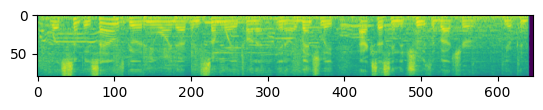

In [61]:
import matplotlib.pyplot as plt

plt.imshow(samples[0]['input_features'])
print(samples[0]['input_features'].shape)

## Data Splitting

The dataset is divided into training, development, and test sets.
The split assignments are saved in a CSV manifest file, which can be used to map each sample to its corresponding split during streaming.

In [42]:
"""
This is the code for counting and saving to csv file


from collections import defaultdict
import pandas as pd

speaker_seen = defaultdict(int)
rows = []

for ex in dataset:
    spk = ex["label"]

    if spk not in speaker2id:
        continue

    speaker_seen[spk] += 1
    utt_idx = speaker_seen[spk]

    total = speaker_count[spk]
    train_cut = int(total * 0.8)
    dev_cut = int(total * 0.9)

    if utt_idx <= train_cut:
        split = "train"
    elif utt_idx <= dev_cut:
        split = "dev"
    else:
        split = "test"

    rows.append({
        "speaker_id": spk,
        "utt_idx": utt_idx,
        "label": speaker2id[spk],
        "split": split,
    })

manifest = pd.DataFrame(rows)
manifest.to_csv("speaker_split_manifest.csv", index=False)
"""

In [62]:
import pandas as pd

manifest = pd.read_csv("speaker_split_manifest.csv")

split_lookup = {
    (row.speaker_id, row.utt_idx): row.split
    for row in manifest.itertuples()
}

In [76]:
from collections import defaultdict

# Reset this counter before iterating through the dataset again.
# Otherwise, utterance indices will continue from the previous run.
speaker_seen = defaultdict(int)

def add_split(example):
    spk = id2speaker[example["label"]]

    speaker_seen[spk] += 1
    utt_idx = speaker_seen[spk]

    example["utt_idx"] = utt_idx
    example["split"] = split_lookup[(spk, utt_idx)]
    return example

In [77]:
dataset_with_split = dataset.map(add_split)

train_dataset = dataset_with_split.filter(lambda ex: ex["split"] == "train")
dev_dataset   = dataset_with_split.filter(lambda ex: ex["split"] == "dev")
test_dataset  = dataset_with_split.filter(lambda ex: ex["split"] == "test")

In [78]:
# can filter out the audio that is too long (use combine with collate_fn),
# or just use fixed audio duration in the prepocess_data function
MAX_T = 3000

train_dataset = train_dataset.filter(
    lambda ex: len(ex["input_features"][0]) <= MAX_T
)

dev_dataset = dev_dataset.filter(
    lambda ex: len(ex["input_features"][0]) <= MAX_T
)

test_dataset = test_dataset.filter(
    lambda ex: len(ex["input_features"][0]) <= MAX_T
)

Check if the splitting works (Don't forget to reset the counter if you try these codes, otherwise after the utt_idx and split would not match)

In [65]:
"""
for i, ex in enumerate(train_dataset):
    print(ex)
    if i == 2:
        break

for i, ex in enumerate(dev_dataset):
    print(ex)
    if i == 2:
        break

for i, ex in enumerate(test_dataset):
    print(ex)
    if i == 2:
        break
"""

{'input_features': array([[ -30.075207 ,  -16.032923 ,   -9.533341 , ..., -100.       ,
        -100.       , -100.       ],
       [ -24.48804  ,  -10.445758 ,   -3.946176 , ..., -100.       ,
        -100.       , -100.       ],
       [  -9.210213 ,   -7.0098753,   -7.9881406, ..., -100.       ,
        -100.       , -100.       ],
       ...,
       [ -25.764101 ,  -32.291344 ,  -33.521503 , ..., -100.       ,
        -100.       , -100.       ],
       [ -29.228725 ,  -34.262573 ,  -31.053612 , ..., -100.       ,
        -100.       , -100.       ],
       [ -33.187565 ,  -35.57962  ,  -35.16908  , ..., -100.       ,
        -100.       , -100.       ]], dtype=float32), 'label': 589, 'utt_idx': 1, 'split': 'train'}
{'input_features': array([[  2.8045108, -14.694378 ,  -4.8928094, ...,   7.8805733,
        -16.851292 , -72.35086  ],
       [  8.391676 ,  -9.107213 ,   0.6943555, ...,  13.467739 ,
        -11.264128 , -66.763695 ],
       [  9.372675 ,  -0.666314 ,   3.2491717, ...,

In [79]:
def collate_fn(batch):
    """
    This is use for dataloader
    Doing padding for each batch
    and tranfer data to tensor
    """
    features = [ex["input_features"] for ex in batch]
    features = [torch.tensor(x, dtype=torch.float32) for x in features]
    labels = [ex["label"] for ex in batch]
    labels = torch.tensor(labels)

    #padding , if using fixed audio duration this can be skipped
    max_T = max(x.shape[1] for x in features)

    padded_features = []
    for x in features:
        pad_T = max_T - x.shape[1]
        x = F.pad(x, (0, pad_T), value=-100.0)   # pad time dimension
        x = x.unsqueeze(0)         # [1, 80, T]
        padded_features.append(x)


    # if usind fixed audio duration stack features directly
    input_features = torch.stack(padded_features)  # [B, 1, 80, max_T]

    return {
        "input_features": input_features,
        "labels": labels
    }

In [80]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    collate_fn=collate_fn
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=32,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    collate_fn=collate_fn
)

In [81]:
batch = next(iter(train_loader))

print(batch["input_features"].shape)  # [B, 1, 80, T]
print(batch["labels"].shape)          # [B]
print(batch["labels"].min(), batch["labels"].max())

torch.Size([32, 1, 80, 1895])
torch.Size([32])
tensor(589) tensor(589)
